# 🧬 Projet : Recommandation des Maladies-Gènes par Prédiction des Liens
## 🎯 Phase 7 — Système de Recommandation Final

---

### 🎯 Objectif de cette phase
Utiliser le meilleur modèle identifié en Phase 6 (**GAE + Random Forest**,
AUC=0.6956) pour construire un vrai système de recommandation :

| Fonction | Entrée | Sortie |
|---|---|---|
| **Maladie → Gènes** | Une maladie connue | Top-K gènes candidats + score de confiance |
| **Gène → Maladies** | Un gène connu | Top-K maladies candidates + score de confiance |

---

### 📖 Méthodologie
On réentraîne le modèle final sur **toutes les données disponibles**
(train + test combinés) pour avoir les prédictions les plus informées
possibles. Ce n'est plus une phase d'évaluation (déjà faite en Phase 5/6),
mais une phase de **déploiement** : on veut le système le plus précis
possible pour recommander de vraies nouvelles associations aux chercheurs.

## ⚙️ Cellule 1 — Chargement de tous les artefacts

In [1]:
import os, pickle, warnings, time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.sparse import lil_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.figsize'] = (13, 7)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

BASE_DIR    = os.path.abspath(os.path.join(os.getcwd(), '..'))
GRAPH_DIR   = os.path.join(BASE_DIR, 'data', 'graph')
SPLIT_DIR   = os.path.join(BASE_DIR, 'data', 'splits')
PROC_DIR    = os.path.join(BASE_DIR, 'data', 'processed')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
FIG_DIR     = os.path.join(BASE_DIR, 'results', 'figures')
RECOM_DIR   = os.path.join(BASE_DIR, 'results', 'recommendations')
os.makedirs(RECOM_DIR, exist_ok=True)

# Graphe COMPLET (toutes les associations connues, Phase 3)
with open(os.path.join(GRAPH_DIR, 'gene_disease_graph.pkl'), 'rb') as f:
    G_full = pickle.load(f)

# Mapping symboles de gènes
df_full = pd.read_csv(os.path.join(PROC_DIR, 'gene_disease_full.csv'), dtype=str)
gene_symbol_map = df_full[['gene_id','gene_symbol']]\
                    .drop_duplicates().set_index('gene_id')['gene_symbol'].to_dict()

gene_nodes    = [n for n in G_full.nodes() if G_full.nodes[n].get('node_type')=='gene']
disease_nodes = [n for n in G_full.nodes() if G_full.nodes[n].get('node_type')=='disease']

print('✅ Données chargées !')
print(f'   Graphe complet : {G_full.number_of_nodes():,} nœuds, {G_full.number_of_edges():,} arêtes')
print(f'   Gènes          : {len(gene_nodes):,}')
print(f'   Maladies       : {len(disease_nodes):,}')

✅ Données chargées !
   Graphe complet : 16,555 nœuds, 15,940 arêtes
   Gènes          : 5,529
   Maladies       : 11,026


## 🤖 Cellule 2 — Entraînement du modèle final (GAE + Random Forest sur G complet)

In [2]:
print('⏳ Recalcul des embeddings GAE sur le graphe COMPLET...')

nodes_list  = list(G_full.nodes())
node_to_idx = {n: i for i, n in enumerate(nodes_list)}
N = len(nodes_list)

A = lil_matrix((N, N), dtype=np.float32)
for u, v in G_full.edges():
    i, j = node_to_idx[u], node_to_idx[v]
    A[i, j] = A[j, i] = 1.0

t0 = time.time()
svd = TruncatedSVD(n_components=64, random_state=42)
gae_matrix = svd.fit_transform(A.tocsr())
embeddings = {nodes_list[i]: gae_matrix[i] for i in range(N)}
print(f'✅ Embeddings recalculés en {time.time()-t0:.1f}s')

# ── Fonction de features (identique aux phases précédentes)
def get_edge_features(u, v, emb, operator='hadamard'):
    if u not in emb or v not in emb:
        dim = len(next(iter(emb.values())))
        return np.zeros(dim)
    eu, ev = emb[u], emb[v]
    return eu * ev   # hadamard

def build_feature_matrix(df, emb):
    X = np.array([get_edge_features(r.node1, r.node2, emb) for r in df.itertuples()])
    y = df['label'].values
    return X, y

# ── Charger train+test (Phase 4) pour entraîner le modèle final
df_train = pd.read_csv(os.path.join(SPLIT_DIR, 'train_data.csv'))
df_test  = pd.read_csv(os.path.join(SPLIT_DIR, 'test_data.csv'))
df_all   = pd.concat([df_train, df_test], ignore_index=True)

X_all, y_all = build_feature_matrix(df_all, embeddings)

print(f'\n⏳ Entraînement du modèle final (Random Forest) sur {len(X_all):,} exemples...')
best_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1))
])
best_model.fit(X_all, y_all)
print('✅ Modèle final entraîné !')

# Sauvegarde
with open(os.path.join(RESULTS_DIR, 'final_model_deployed.pkl'), 'wb') as f:
    pickle.dump({'model': best_model, 'embeddings': embeddings}, f)
print('💾 Modèle sauvegardé → results/final_model_deployed.pkl')

⏳ Recalcul des embeddings GAE sur le graphe COMPLET...
✅ Embeddings recalculés en 3.6s

⏳ Entraînement du modèle final (Random Forest) sur 31,880 exemples...
✅ Modèle final entraîné !
💾 Modèle sauvegardé → results/final_model_deployed.pkl


## 🔧 Cellule 3 — Construction du système de recommandation

In [3]:
class GeneDiseasRecommender:
    def __init__(self, model, embeddings, G, gene_symbol_map):
        self.model        = model
        self.embeddings    = embeddings
        self.G             = G
        self.gene_sym_map  = gene_symbol_map
        self.gene_nodes    = [n for n in G.nodes() if G.nodes[n].get('node_type')=='gene']
        self.disease_nodes = [n for n in G.nodes() if G.nodes[n].get('node_type')=='disease']

    def _score_pairs(self, pairs):
        X = np.array([get_edge_features(u, v, self.embeddings) for u, v in pairs])
        if X.shape[0] == 0:
            return np.array([])
        return self.model.predict_proba(X)[:, 1]

    def _confidence(self, score):
        if score >= 0.70: return '🔴 TRÈS HAUTE'
        elif score >= 0.55: return '🟠 HAUTE'
        elif score >= 0.40: return '🟡 MOYENNE'
        else: return '⚪ FAIBLE'

    def recommend_genes_for_disease(self, disease_id, top_k=10):
        if disease_id not in self.G:
            return pd.DataFrame({'Erreur': [f'{disease_id} non trouvée']})
        known = set(self.G.neighbors(disease_id))
        candidates = [g for g in self.gene_nodes if g not in known and g in self.embeddings]
        pairs  = [(disease_id, g) for g in candidates]
        scores = self._score_pairs(pairs)
        top_idx = np.argsort(scores)[::-1][:top_k]

        rows = []
        for rank, idx in enumerate(top_idx, 1):
            gene_node = candidates[idx]
            gid = gene_node.replace('G_','')
            rows.append({
                'Rang': rank,
                'Gène': self.gene_sym_map.get(gid, gid),
                'ID Gène': gid,
                'Score IA': round(float(scores[idx]), 4),
                'Confiance': self._confidence(scores[idx]),
                'Deg. gène': self.G.degree(gene_node)
            })
        return pd.DataFrame(rows)

    def recommend_diseases_for_gene(self, gene_node, top_k=10):
        if gene_node not in self.G:
            return pd.DataFrame({'Erreur': [f'{gene_node} non trouvé']})
        known = set(self.G.neighbors(gene_node))
        candidates = [d for d in self.disease_nodes if d not in known and d in self.embeddings]
        pairs  = [(gene_node, d) for d in candidates]
        scores = self._score_pairs(pairs)
        top_idx = np.argsort(scores)[::-1][:top_k]

        rows = []
        for rank, idx in enumerate(top_idx, 1):
            dis_node = candidates[idx]
            rows.append({
                'Rang': rank,
                'Maladie ID': dis_node.replace('D_',''),
                'Score IA': round(float(scores[idx]), 4),
                'Confiance': self._confidence(scores[idx]),
                'Deg. maladie': self.G.degree(dis_node)
            })
        return pd.DataFrame(rows)


recommender = GeneDiseasRecommender(best_model, embeddings, G_full, gene_symbol_map)
print('🎉 Système de recommandation prêt !')

🎉 Système de recommandation prêt !


## 🔍 Cellule 4 — Sélection des exemples pour la démo

In [4]:
top_genes_deg    = sorted([(n, G_full.degree(n)) for n in gene_nodes], key=lambda x: x[1], reverse=True)
top_diseases_deg = sorted([(n, G_full.degree(n)) for n in disease_nodes], key=lambda x: x[1], reverse=True)

EXAMPLE_GENE_NODE    = top_genes_deg[0][0]
EXAMPLE_DISEASE_NODE = top_diseases_deg[0][0]
example_gene_sym = gene_symbol_map.get(EXAMPLE_GENE_NODE.replace('G_',''), EXAMPLE_GENE_NODE)

print(f'📌 Gène exemple    : {example_gene_sym} ({EXAMPLE_GENE_NODE}) — {G_full.degree(EXAMPLE_GENE_NODE)} maladies connues')
print(f'📌 Maladie exemple : {EXAMPLE_DISEASE_NODE} — {G_full.degree(EXAMPLE_DISEASE_NODE)} gènes connus')

📌 Gène exemple    : HBB (G_3043) — 37 maladies connues
📌 Maladie exemple : D_ORPHA:528084 — 114 gènes connus


## 🦠 Cellule 5 — Démo : Maladie → Top-10 Gènes candidats

In [5]:
recs_disease = recommender.recommend_genes_for_disease(EXAMPLE_DISEASE_NODE, top_k=10)
print(f'🔮 Top 10 gènes candidats pour {EXAMPLE_DISEASE_NODE} :\n')
print(recs_disease.to_string(index=False))

recs_disease.to_csv(os.path.join(RECOM_DIR, 'rec_genes_example.csv'), index=False)

🔮 Top 10 gènes candidats pour D_ORPHA:528084 :

 Rang   Gène ID Gène  Score IA    Confiance  Deg. gène
    1 WASHC5    9897    0.9867 🔴 TRÈS HAUTE          4
    2 CCDC22   28952    0.9867 🔴 TRÈS HAUTE          2
    3 VPS35L   57020    0.9867 🔴 TRÈS HAUTE          2
    4  BRPF1    7862    0.9867 🔴 TRÈS HAUTE          2
    5 SLC2A3    6515    0.9733 🔴 TRÈS HAUTE          1
    6  RBBP7    5931    0.6756      🟠 HAUTE          1
    7   CLPX   10845    0.6756      🟠 HAUTE          1
    8  KIF3B    9371    0.6756      🟠 HAUTE          1
    9  EIF4E    1977    0.6756      🟠 HAUTE          1
   10   UBR5   51366    0.6756      🟠 HAUTE          1


## 📊 Cellule 6 — Visualisation de cette recommandation

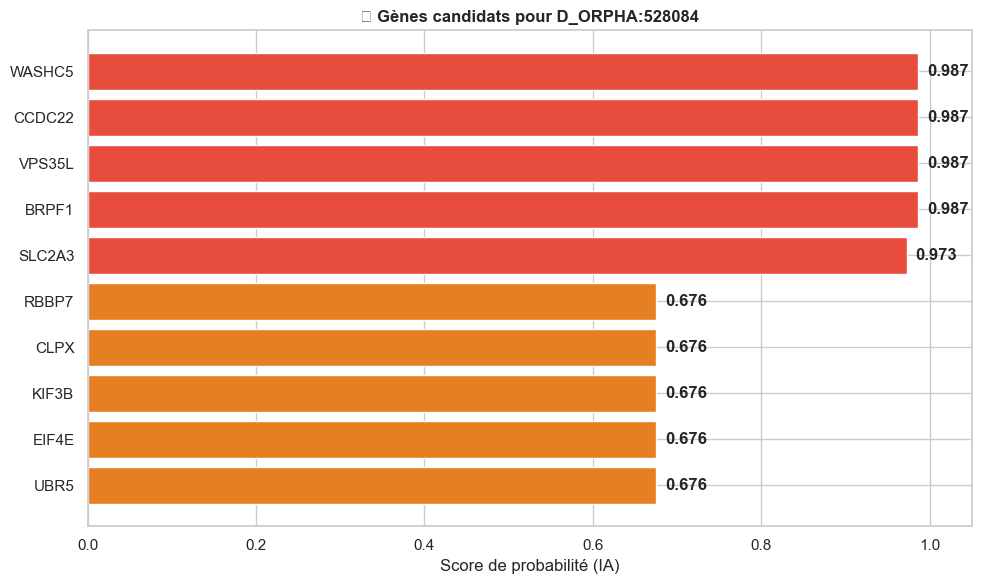

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E74C3C' if s>=0.7 else '#E67E22' if s>=0.55 else '#F1C40F' if s>=0.4 else '#95A5A6'
          for s in recs_disease['Score IA']]
bars = ax.barh(recs_disease['Gène'][::-1], recs_disease['Score IA'][::-1],
              color=colors[::-1], edgecolor='white')
for bar, val in zip(bars, recs_disease['Score IA'][::-1]):
    ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontweight='bold')
ax.set_xlabel('Score de probabilité (IA)')
ax.set_title(f'🔮 Gènes candidats pour {EXAMPLE_DISEASE_NODE}', fontweight='bold')
ax.set_xlim([0, 1.05])
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'rec_disease_demo.png'), dpi=150, bbox_inches='tight')
plt.show()

## 🧬 Cellule 7 — Démo : Gène → Top-10 Maladies candidates

In [7]:
recs_gene = recommender.recommend_diseases_for_gene(EXAMPLE_GENE_NODE, top_k=10)
print(f'🔮 Top 10 maladies candidates pour le gène {example_gene_sym} :\n')
print(recs_gene.to_string(index=False))

recs_gene.to_csv(os.path.join(RECOM_DIR, 'rec_diseases_example.csv'), index=False)

🔮 Top 10 maladies candidates pour le gène HBB :

 Rang   Maladie ID  Score IA    Confiance  Deg. maladie
    1 ORPHA:330032    0.9000 🔴 TRÈS HAUTE             1
    2 ORPHA:619233    0.7733 🔴 TRÈS HAUTE             1
    3  OMIM:617101    0.7733 🔴 TRÈS HAUTE             1
    4 ORPHA:280615    0.7600 🔴 TRÈS HAUTE             1
    5  OMIM:613977    0.7600 🔴 TRÈS HAUTE             1
    6 ORPHA:707792    0.7600 🔴 TRÈS HAUTE             1
    7  OMIM:609820    0.7400 🔴 TRÈS HAUTE             1
    8  OMIM:613566    0.7400 🔴 TRÈS HAUTE             1
    9  OMIM:617907    0.7400 🔴 TRÈS HAUTE             1
   10  OMIM:620969    0.7400 🔴 TRÈS HAUTE             1


## 📊 Cellule 8 — Visualisation de cette recommandation

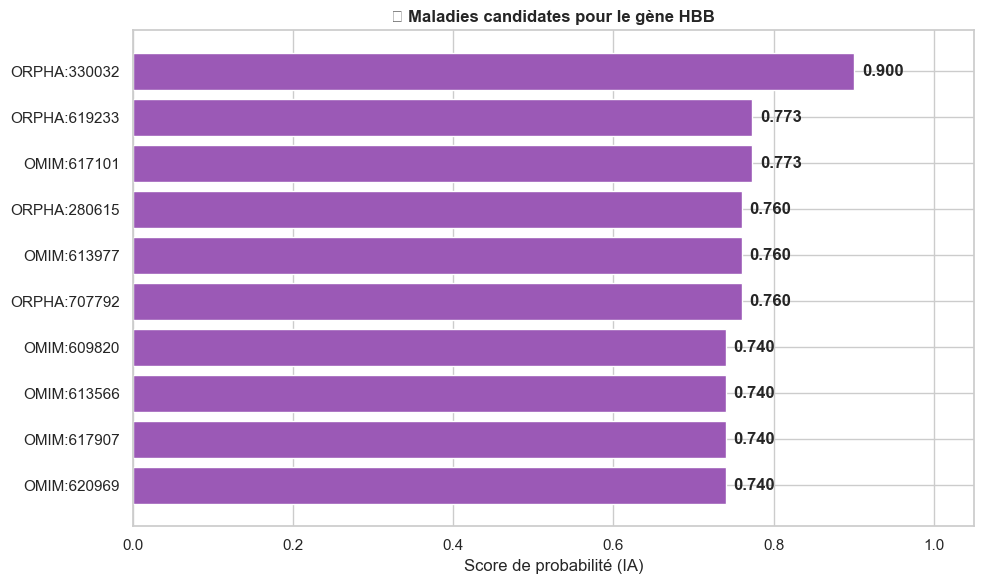

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#9B59B6' if s>=0.7 else '#3498DB' if s>=0.55 else '#1ABC9C' if s>=0.4 else '#95A5A6'
          for s in recs_gene['Score IA']]
bars = ax.barh(recs_gene['Maladie ID'][::-1], recs_gene['Score IA'][::-1],
              color=colors[::-1], edgecolor='white')
for bar, val in zip(bars, recs_gene['Score IA'][::-1]):
    ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontweight='bold')
ax.set_xlabel('Score de probabilité (IA)')
ax.set_title(f'🔮 Maladies candidates pour le gène {example_gene_sym}', fontweight='bold')
ax.set_xlim([0, 1.05])
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'rec_gene_demo.png'), dpi=150, bbox_inches='tight')
plt.show()

## 📋 Cellule 9 — Test sur plusieurs maladies (cascade)

In [9]:
top5_diseases = [node for node, _ in top_diseases_deg[:5]]
all_recs = []

print('🔍 RECOMMANDATIONS POUR LES 5 MALADIES LES PLUS CONNECTÉES\n')
for dis_node in top5_diseases:
    recs = recommender.recommend_genes_for_disease(dis_node, top_k=5)
    print(f'🦠 {dis_node} ({G_full.degree(dis_node)} gènes déjà connus)')
    for _, row in recs.iterrows():
        print(f'   {row["Rang"]}. {row["Gène"]:<12} score={row["Score IA"]:.3f}  {row["Confiance"]}')
        all_recs.append({'Maladie': dis_node, **row.to_dict()})
    print()

pd.DataFrame(all_recs).to_csv(os.path.join(RECOM_DIR, 'top5_diseases_recommendations.csv'), index=False)
print('💾 Sauvegardé → results/recommendations/top5_diseases_recommendations.csv')

🔍 RECOMMANDATIONS POUR LES 5 MALADIES LES PLUS CONNECTÉES

🦠 D_ORPHA:528084 (114 gènes déjà connus)
   1. WASHC5       score=0.987  🔴 TRÈS HAUTE
   2. CCDC22       score=0.987  🔴 TRÈS HAUTE
   3. VPS35L       score=0.987  🔴 TRÈS HAUTE
   4. BRPF1        score=0.987  🔴 TRÈS HAUTE
   5. SLC2A3       score=0.973  🔴 TRÈS HAUTE

🦠 D_ORPHA:791 (88 gènes déjà connus)
   1. HP           score=1.000  🔴 TRÈS HAUTE
   2. GRK1         score=0.973  🔴 TRÈS HAUTE
   3. GNAT1        score=0.967  🔴 TRÈS HAUTE
   4. CLCF1        score=0.913  🔴 TRÈS HAUTE
   5. AIPL1        score=0.860  🔴 TRÈS HAUTE

🦠 D_ORPHA:90636 (74 gènes déjà connus)
   1. SLC12A3      score=0.893  🔴 TRÈS HAUTE
   2. USH1G        score=0.867  🔴 TRÈS HAUTE
   3. OR2J3        score=0.817  🔴 TRÈS HAUTE
   4. IVNS1ABP     score=0.785  🔴 TRÈS HAUTE
   5. ARFGEF1      score=0.785  🔴 TRÈS HAUTE

🦠 D_ORPHA:88616 (54 gènes déjà connus)
   1. TAF8         score=1.000  🔴 TRÈS HAUTE
   2. MRPS25       score=1.000  🔴 TRÈS HAUTE
   3. SEC31A     

## ✅ Cellule 10 — Résumé final du projet complet

In [10]:
print('╔══════════════════════════════════════════════════════════════╗')
print('║       🎉 PROJET COMPLET — TOUTES LES PHASES TERMINÉES !      ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  ✅ Phase 1 — Compréhension et cadrage théorique             ║')
print('║  ✅ Phase 2 — Collecte et préparation des données HPO        ║')
print('║  ✅ Phase 3 — Construction du graphe biparti (NetworkX)      ║')
print('║  ✅ Phase 4 — Préparation Train/Test + exemples négatifs     ║')
print('║  ✅ Phase 5 — Méthodes baseline (AUC max = 0.5751)           ║')
print('║  ✅ Phase 6 — Méthodes IA : GAE+RF (AUC = 0.6956)            ║')
print('║  ✅ Phase 7 — Système de recommandation final                ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  🏆 Gain final : +12.05 points AUC (IA vs Baseline)          ║')
print('║  🏆 Meilleur modèle : GAE + Random Forest                    ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  📁 Tous les résultats sont dans results/recommendations/    ║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║       🎉 PROJET COMPLET — TOUTES LES PHASES TERMINÉES !      ║
╠══════════════════════════════════════════════════════════════╣
║  ✅ Phase 1 — Compréhension et cadrage théorique             ║
║  ✅ Phase 2 — Collecte et préparation des données HPO        ║
║  ✅ Phase 3 — Construction du graphe biparti (NetworkX)      ║
║  ✅ Phase 4 — Préparation Train/Test + exemples négatifs     ║
║  ✅ Phase 5 — Méthodes baseline (AUC max = 0.5751)           ║
║  ✅ Phase 6 — Méthodes IA : GAE+RF (AUC = 0.6956)            ║
║  ✅ Phase 7 — Système de recommandation final                ║
╠══════════════════════════════════════════════════════════════╣
║  🏆 Gain final : +12.05 points AUC (IA vs Baseline)          ║
║  🏆 Meilleur modèle : GAE + Random Forest                    ║
╠══════════════════════════════════════════════════════════════╣
║  📁 Tous les résultats sont dans results/recommendations/    ║
╚═══════════════════════════════════